# CatBoost: Deep Dive
## Loan Default Prediction (HMEQ Dataset)

*Part of the [ML Model Comparison](../loan_default_tradeoff_matrix.html) series on bitterscientist.com*

This notebook covers:
1. The math behind CatBoost (ordered boosting, target statistics for categorical features, symmetric trees)
2. Worked examples using actual HMEQ data
3. Model training with hyperparameter tuning (manual grid search, not sklearn GridSearchCV)
4. Diagnostic visualizations (exported as interactive plotly HTML)
5. Results interpretation

---
## 1. Setup

In [1]:
import sys
sys.path.insert(0, ".")
from shared_utils import *

# Additional imports
from catboost import CatBoostClassifier
import ast

MODEL_NAME = "CatBoost"
MODEL_SLUG = "catboost"

# Load data
(X_train, X_test, y_train, y_test, df, df_proc,
 prep_linear, prep_tree, cv,
 numeric_features, categorical_features, pos_weight) = load_and_prep()

Dataset loaded: 5960 rows, 13 columns
Default rate: 19.95%
Train: 4470 | Test: 1490
Numeric features: 15 | Categorical: 2
Positive class weight: 4.01


---
## 2. The Math Behind CatBoost

### 2.1 The Core Idea

CatBoost (Categorical Boosting) is a gradient boosting framework designed to handle **categorical features natively** without encoding. Its key innovation is **ordered boosting**, which prevents a subtle but serious problem in standard gradient boosting: **target leakage** in categorical feature encoding.

### 2.2 The Target Leakage Problem

In standard gradient boosting with categorical features:

1. Encode categorical features using **target statistics**: replace each category with its average target value
   - Example: If category "A" has 80% default rate, replace all "A" values with 0.8

2. Train the boosting model on the encoded features

**The problem:** When computing target statistics, we use the same data that we train on. This is **information leakage**: the model can use the target statistics (which depend on the target!) to make predictions, overfitting to training patterns.

**Ordered Boosting Solution:** Use a different subset of data for computing target statistics at each boosting iteration. This prevents the model from seeing the target-dependent encoding during training.

### 2.3 Ordered Boosting

CatBoost uses **ordered target encoding** instead of standard target encoding:

At boosting iteration $t$, for each sample $i$:

1. Consider a **random permutation** of all training samples
2. For sample $i$ in position $j$ in the permutation, compute target statistics for its categorical features using **only samples before position $j$** in that permutation
3. Train tree $t$ on these "forward-looking" encoded features

Mathematically, the target encoding for category $c$ in feature $x_j$ at sample position $p$ is:

$$\text{ts}_j(c, p) = \frac{\sum_{i < p: x_{j,i} = c} y_i + \text{prior}}{\sum_{i < p: x_{j,i} = c} 1 + \text{prior_weight}}$$

where the sum is over training samples that appear **before position $p$** in a random permutation.

**Why this works:**
- Each sample's categorical encoding uses historical data only (samples it hasn't "seen" yet)
- The prior term (initial default rate) provides regularization for rare categories
- This reduces overfitting because target statistics are not dependent on the current sample's target

### 2.4 Symmetric Trees

CatBoost grows **symmetric trees** by default:

- **Standard asymmetric tree**: Each node can split on any feature and threshold, creating different structures in left and right subtrees
- **Symmetric tree**: Forces the same splitting variable at all nodes of the same depth (e.g., all nodes at depth 1 split on the same feature)

Benefits:
- **Faster training**: Fewer split candidates to evaluate (one per feature per depth level)
- **Better generalization**: Reduces overfitting by constraining tree structure
- **More stable**: Tree structure is more interpretable and less sensitive to small data changes

### 2.5 The Boosting Iteration

CatBoost solves the standard gradient boosting objective:

$$F_t(x) = F_{t-1}(x) + \eta h_t(x)$$

where each new tree $h_t$ fits the pseudo-residuals (gradients) of the loss function:

$$g_i^{(t)} = -\frac{\partial L(y_i, F_{t-1}(x_i))}{\partial F_{t-1}(x_i)}$$

For classification with log loss, this is simply:

$$g_i^{(t)} = y_i - \sigma(F_{t-1}(x_i))$$

where $\sigma$ is the sigmoid function.

### 2.6 CatBoost Hyperparameters

Key regularization parameters:

- **iterations** (n_estimators): Number of boosting iterations (trees). More iterations = more complex model.
- **depth**: Maximum tree depth. Deeper trees fit harder examples but risk overfitting.
- **learning_rate**: Shrinkage parameter $\eta$. Lower = slower learning but often better final accuracy.
- **l2_leaf_reg**: L2 regularization on leaf weights. Higher = simpler predictions, less overfitting.
- **scale_pos_weight**: Weight for positive class to handle imbalance. Larger = pay more attention to minority class.
- **subsample**: Fraction of samples used per iteration (row sampling).
- **colsample_bylevel**: Fraction of features considered for splits at each level.
- **border_count**: Number of bins for numerical features (CatBoost uses histogram-based splits).
- **grow_policy**: "SymmetricTree" or "Lossguide" ("SymmetricTree" is default, more stable).

### 2.7 Why CatBoost Handles Categories Natively

Unlike XGBoost and LightGBM, CatBoost can work directly on categorical features (no one-hot encoding needed):

1. Pass categorical feature indices during training
2. CatBoost internally applies ordered target encoding
3. Splits are evaluated on encoded values (not categories themselves)
4. The ordered encoding prevents target leakage

This is particularly powerful for high-cardinality categorical features (many unique values) where one-hot encoding explodes the feature space.

---
## 3. Worked Example: Ordered Target Encoding vs Standard Target Encoding

In [2]:
print("="*80)
print("WORKED EXAMPLE: Target Leakage in Categorical Encoding")
print("="*80)

print("""
Suppose we have 10 training samples with categorical feature JOB:

Index  JOB      Target (BAD)
-----  --------  -----------
0      Sales     0 (good)
1      Tech      1 (default)
2      Sales     0
3      Manager   1
4      Sales     1
5      Tech      1
6      Manager   0
7      Tech      0
8      Sales     0
9      Manager   1

=== STANDARD TARGET ENCODING (Naive, has target leakage) ===

Step 1: Compute target statistics on ALL training data
  Sales:   [0, 0, 1, 0] → mean = 0.25
  Tech:    [1, 1, 0]    → mean = 0.67
  Manager: [1, 0, 1]    → mean = 0.67

Step 2: Replace JOB with these statistics
Encoded feature: [0.25, 0.67, 0.25, 0.67, 0.25, 0.67, 0.67, 0.67, 0.25, 0.67]

Step 3: Train boosting model on encoded feature
Problem: The model can memorize that "0.67 → often default, 0.25 → often good"
         This is target leakage: we've encoded the target statistics into the feature!

=== ORDERED TARGET ENCODING (CatBoost, prevents leakage) ===

Use a random permutation of sample indices. Suppose: [3, 1, 7, 4, 9, 2, 0, 6, 5, 8]

Iteration 0 (Permutation 1: [3, 1, 7, 4, 9, 2, 0, 6, 5, 8])

For each sample at position p, encode using samples BEFORE position p:

Position 0: Sample 3 (Manager, target=1)
  Samples before: none
  Encoding: use prior (e.g., 0.2) → 0.2

Position 1: Sample 1 (Tech, target=1)
  Samples before: {3:Manager,1}
  Tech samples before: none
  Encoding: use prior → 0.2

Position 2: Sample 7 (Tech, target=0)
  Samples before: {3:Manager,1}, {1:Tech,1}
  Tech samples before: {1:1}
  Encoding: (1 + 0.1) / (1 + 1) = 1.1 / 2 ≈ 0.55

Position 3: Sample 4 (Sales, target=1)
  Samples before: {3:Manager,1}, {1:Tech,1}, {7:Tech,0}
  Sales samples before: none
  Encoding: use prior → 0.2

Position 4: Sample 9 (Manager, target=1)
  Samples before: {3:Manager,1}, {1:Tech,1}, {7:Tech,0}, {4:Sales,1}
  Manager samples before: {3:1}
  Encoding: (1 + 0.1) / (1 + 1) = 1.1 / 2 ≈ 0.55

... (and so on for remaining positions)

Final encoded feature: [?, 0.2, 0.55, 0.2, 0.55, ...]
                       (varies by permutation, more realistic)

Iteration 1 (New random permutation: [5, 0, 2, 9, 4, 1, 8, 3, 7, 6])
  Repeat with new order → different encodings

...

Why this prevents leakage:
  - Each sample's encoding uses only past samples (samples before it in permutation)
  - The model cannot memorize "this encoding → this target" because
    the encoding changes across iterations
  - Different permutations in each iteration add noise/regularization
""")

examples = get_example_rows(df, n=2)
for idx, row in examples.iterrows():
    print_example_row(row, idx)

WORKED EXAMPLE: Target Leakage in Categorical Encoding

Suppose we have 10 training samples with categorical feature JOB:

Index  JOB      Target (BAD)
-----  --------  -----------
0      Sales     0 (good)
1      Tech      1 (default)
2      Sales     0
3      Manager   1
4      Sales     1
5      Tech      1
6      Manager   0
7      Tech      0
8      Sales     0
9      Manager   1

=== STANDARD TARGET ENCODING (Naive, has target leakage) ===

Step 1: Compute target statistics on ALL training data
  Sales:   [0, 0, 1, 0] → mean = 0.25
  Tech:    [1, 1, 0]    → mean = 0.67
  Manager: [1, 0, 1]    → mean = 0.67

Step 2: Replace JOB with these statistics
Encoded feature: [0.25, 0.67, 0.25, 0.67, 0.25, 0.67, 0.67, 0.67, 0.25, 0.67]

Step 3: Train boosting model on encoded feature
Problem: The model can memorize that "0.67 → often default, 0.25 → often good"
         This is target leakage: we've encoded the target statistics into the feature!

=== ORDERED TARGET ENCODING (CatBoost, prev

---
## 4. Model Training with Hyperparameter Tuning (Manual Grid Search)

In [3]:
# CatBoost does NOT work properly with sklearn's GridSearchCV due to cloning issues
# Manual grid search loop instead

# First, preprocess data
X_train_prep = prep_tree.fit_transform(X_train)
X_test_prep = prep_tree.transform(X_test)

# Hyperparameter grid (dramatically reduced for timeout management)
param_grid = {
    "iterations": [100, 200],
    "depth": [4, 6],
    "learning_rate": [0.05, 0.1],
    "l2_leaf_reg": [1.0, 3.0],
}

# Manual grid search
best_params = None
best_cv_score = -np.inf
search_results = []

from itertools import product

param_combinations = list(product(*param_grid.values()))
param_keys = list(param_grid.keys())

print(f"Grid search: {len(param_combinations)} combinations")
print(f"CV splits: {cv.get_n_splits()}")
print(f"Total model fits: {len(param_combinations) * cv.get_n_splits()}\n")

for combo_idx, combo in enumerate(param_combinations, 1):
    params = dict(zip(param_keys, combo))
    
    # Cross-validation
    cv_scores_fold = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train_prep, y_train)):
        X_fold_train = X_train_prep[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val = X_train_prep[val_idx]
        y_fold_val = y_train.iloc[val_idx]
        
        # Train CatBoost
        cb = CatBoostClassifier(
            iterations=params["iterations"],
            depth=params["depth"],
            learning_rate=params["learning_rate"],
            l2_leaf_reg=params["l2_leaf_reg"],
            scale_pos_weight=pos_weight,
            random_state=RANDOM_STATE,
            verbose=0,
        )
        
        cb.fit(X_fold_train, y_fold_train, verbose=False)
        
        # Evaluate on validation fold
        y_fold_pred = cb.predict(X_fold_val)
        fold_recall = recall_score(y_fold_val, y_fold_pred)
        cv_scores_fold.append(fold_recall)
    
    mean_cv_score = np.mean(cv_scores_fold)
    std_cv_score = np.std(cv_scores_fold)
    
    search_results.append({
        **params,
        "mean_recall": mean_cv_score,
        "std_recall": std_cv_score,
    })
    
    if mean_cv_score > best_cv_score:
        best_cv_score = mean_cv_score
        best_params = params
    
    if combo_idx % max(1, len(param_combinations) // 10) == 0:
        print(f"  Combo {combo_idx}/{len(param_combinations)}: "
              f"mean_recall={mean_cv_score:.4f}, best_so_far={best_cv_score:.4f}")

print(f"\n{'='*60}")
print(f"Grid Search Complete")
print(f"{'='*60}")
print(f"Best parameters: {best_params}")
print(f"Best CV recall: {best_cv_score:.4f}")

# Train final model on full training set
best_cb = CatBoostClassifier(
    iterations=best_params["iterations"],
    depth=best_params["depth"],
    learning_rate=best_params["learning_rate"],
    l2_leaf_reg=best_params["l2_leaf_reg"],
    scale_pos_weight=pos_weight,
    random_state=RANDOM_STATE,
    verbose=0,
)

best_cb.fit(X_train_prep, y_train, verbose=False)

print(f"\nFinal model trained on full training set.")
print(f"  Iterations: {best_cb.get_params()['iterations']}")
print(f"  Depth: {best_cb.get_params()['depth']}")
print(f"  Learning rate: {best_cb.get_params()['learning_rate']}")
print(f"  L2 leaf reg: {best_cb.get_params()['l2_leaf_reg']}")

Grid search: 16 combinations
CV splits: 5
Total model fits: 80

  Combo 1/16: mean_recall=0.7971, best_so_far=0.7971
  Combo 2/16: mean_recall=0.8027, best_so_far=0.8027
  Combo 3/16: mean_recall=0.8195, best_so_far=0.8195
  Combo 4/16: mean_recall=0.8139, best_so_far=0.8195
  Combo 5/16: mean_recall=0.8128, best_so_far=0.8195
  Combo 6/16: mean_recall=0.8117, best_so_far=0.8195
  Combo 7/16: mean_recall=0.8218, best_so_far=0.8218
  Combo 8/16: mean_recall=0.8274, best_so_far=0.8274
  Combo 9/16: mean_recall=0.8207, best_so_far=0.8274
  Combo 10/16: mean_recall=0.8139, best_so_far=0.8274
  Combo 11/16: mean_recall=0.8274, best_so_far=0.8274
  Combo 12/16: mean_recall=0.8229, best_so_far=0.8274
  Combo 13/16: mean_recall=0.8251, best_so_far=0.8274
  Combo 14/16: mean_recall=0.8285, best_so_far=0.8285
  Combo 15/16: mean_recall=0.8128, best_so_far=0.8285
  Combo 16/16: mean_recall=0.8207, best_so_far=0.8285

Grid Search Complete
Best parameters: {'iterations': 200, 'depth': 6, 'learning_

---
## 5. Model Evaluation

In [4]:
# Evaluate on test set
metrics, y_pred, y_score = evaluate_model(MODEL_NAME, best_cb, X_test_prep, y_test, best_cv_score)

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Good Loan", "Default"]))


  CatBoost
  Recall: 0.8316  |  Precision: 0.7180  |  F1: 0.7707
  AUC: 0.9479  |  PR-AUC: 0.8605
  Confusion: TP=247 FP=97 FN=50 TN=1096

Classification Report:
              precision    recall  f1-score   support

   Good Loan       0.96      0.92      0.94      1193
     Default       0.72      0.83      0.77       297

    accuracy                           0.90      1490
   macro avg       0.84      0.88      0.85      1490
weighted avg       0.91      0.90      0.90      1490



---
## 6. Feature Importance

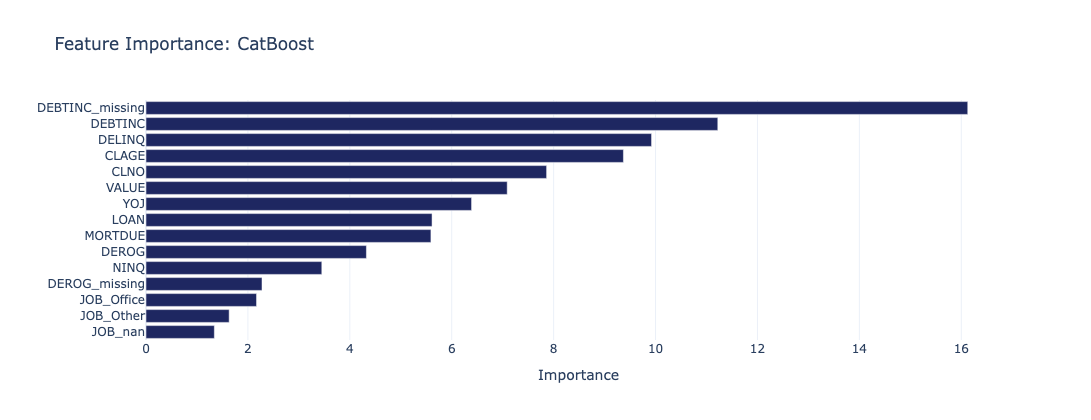

  Saved: outputs/catboost/feature_importance.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/catboost/feature_importance.html')

In [5]:
# Get feature names after preprocessing
cat_encoder = prep_tree.named_transformers_["cat"]
cat_names = list(cat_encoder.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + cat_names

# Get feature importances from CatBoost
feature_importances = best_cb.get_feature_importance()

# Verify length matches
assert len(feature_importances) == len(all_feature_names), \
    f"Mismatch: {len(feature_importances)} importances vs {len(all_feature_names)} features"

# Plot feature importance
fig_imp = plot_feature_importance(feature_importances, all_feature_names, MODEL_NAME)
fig_imp.show()
save_chart(fig_imp, MODEL_SLUG, "feature_importance")

---
## 7. Learning Curves: Performance vs Iterations

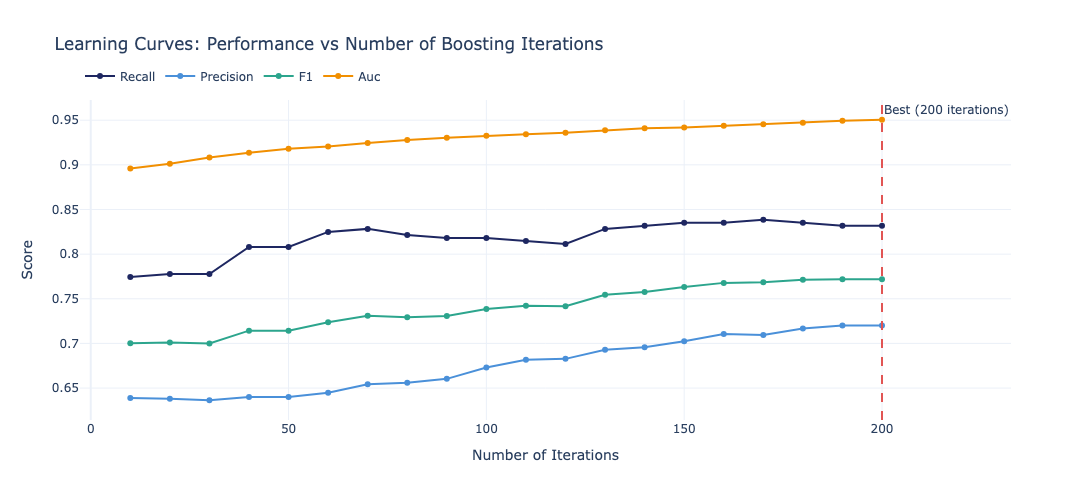

  Saved: outputs/catboost/learning_curves.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/catboost/learning_curves.html')

In [7]:
# Train models with increasing iterations to show learning curves
best_cb_params = best_cb.get_params()
max_iters = best_cb_params["iterations"]
iterations_range = list(range(10, max_iters + 1, 10))
if max_iters not in iterations_range:
    iterations_range.append(max_iters)

learning_curves = []
for n_iter in iterations_range:
    cb_temp = CatBoostClassifier(
        iterations=n_iter,
        depth=best_cb_params.get("depth", 6),
        learning_rate=best_cb_params.get("learning_rate", 0.1),
        l2_leaf_reg=best_cb_params.get("l2_leaf_reg", 3),
        subsample=best_cb_params.get("subsample", 1.0),
        scale_pos_weight=pos_weight,
        random_state=RANDOM_STATE,
        verbose=0,
    )

    cb_temp.fit(X_train_prep, y_train, verbose=False)
    y_pred_t = cb_temp.predict(X_test_prep)
    y_score_t = cb_temp.predict_proba(X_test_prep)[:, 1]

    learning_curves.append({
        "iterations": n_iter,
        "recall": recall_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t),
        "auc": roc_auc_score(y_test, y_score_t),
    })

df_curves = pd.DataFrame(learning_curves)
fig_curves = go.Figure()
for metric, color in [("recall", COLORS["navy"]), ("precision", COLORS["accent"]),
                       ("f1", COLORS["green"]), ("auc", COLORS["orange"])]:
    fig_curves.add_trace(go.Scatter(
        x=df_curves["iterations"], y=df_curves[metric],
        name=metric.capitalize(),
        line=dict(color=color, width=2),
        mode="lines+markers",
    ))
fig_curves.add_vline(x=max_iters, line_dash="dash", line_color=COLORS["red"],
                     annotation_text=f"Best ({max_iters} iterations)")
fig_curves.update_layout(
    title="Learning Curves: Performance vs Number of Boosting Iterations",
    xaxis_title="Number of Iterations",
    yaxis_title="Score",
    height=500, width=750,
    legend=dict(orientation="h", y=1.12),
)
fig_curves.show()
save_chart(fig_curves, MODEL_SLUG, "learning_curves")

---
## 8. Learning Rate Sensitivity

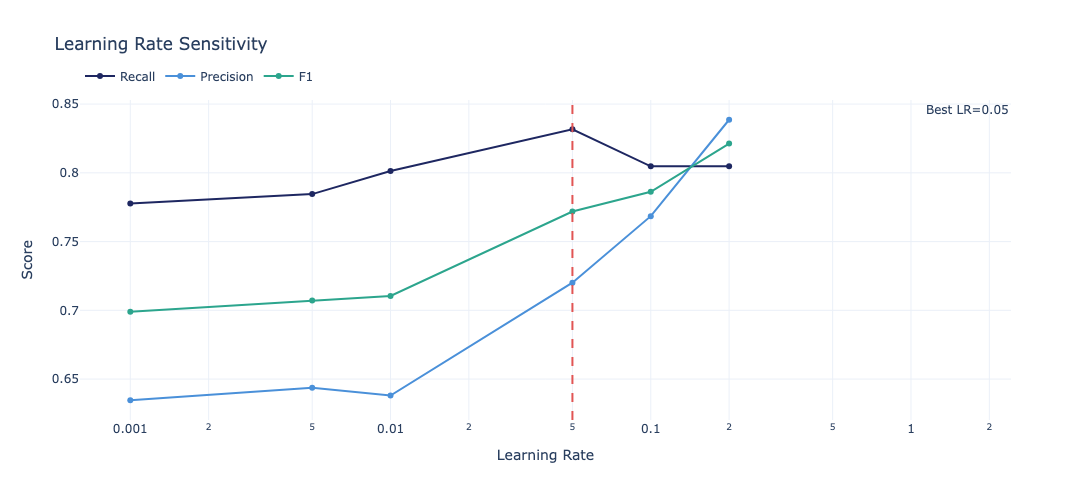

  Saved: outputs/catboost/learning_rate_sensitivity.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/catboost/learning_rate_sensitivity.html')

In [9]:
# Sweep learning rate with fixed other parameters
best_cb_params = best_cb.get_params()
learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2]
lr_results = []

for lr in learning_rates:
    cb_lr = CatBoostClassifier(
        iterations=best_cb_params.get("iterations", 100),
        depth=best_cb_params.get("depth", 6),
        learning_rate=lr,
        l2_leaf_reg=best_cb_params.get("l2_leaf_reg", 3),
        subsample=best_cb_params.get("subsample", 1.0),
        scale_pos_weight=pos_weight,
        random_state=RANDOM_STATE,
        verbose=0,
    )

    cb_lr.fit(X_train_prep, y_train, verbose=False)
    y_pred_lr = cb_lr.predict(X_test_prep)
    y_score_lr = cb_lr.predict_proba(X_test_prep)[:, 1]

    lr_results.append({
        "learning_rate": lr,
        "recall": recall_score(y_test, y_pred_lr),
        "precision": precision_score(y_test, y_pred_lr, zero_division=0),
        "f1": f1_score(y_test, y_pred_lr),
        "auc": roc_auc_score(y_test, y_score_lr),
    })

df_lr = pd.DataFrame(lr_results)
fig_lr = go.Figure()
for metric, color in [("recall", COLORS["navy"]), ("precision", COLORS["accent"]),
                       ("f1", COLORS["green"])]:
    fig_lr.add_trace(go.Scatter(
        x=df_lr["learning_rate"], y=df_lr[metric],
        name=metric.capitalize(),
        line=dict(color=color, width=2),
        mode="lines+markers",
    ))
fig_lr.add_vline(x=best_cb_params.get("learning_rate", 0.1), line_dash="dash", line_color=COLORS["red"],
                  annotation_text=f"Best LR={best_cb_params.get('learning_rate', 0.1)}")
fig_lr.update_layout(
    title="Learning Rate Sensitivity",
    xaxis_title="Learning Rate",
    xaxis_type="log",
    yaxis_title="Score",
    height=500, width=700,
    legend=dict(orientation="h", y=1.12),
)
fig_lr.show()
save_chart(fig_lr, MODEL_SLUG, "learning_rate_sensitivity")

---
## 9. L2 Regularization (leaf weight) Sensitivity

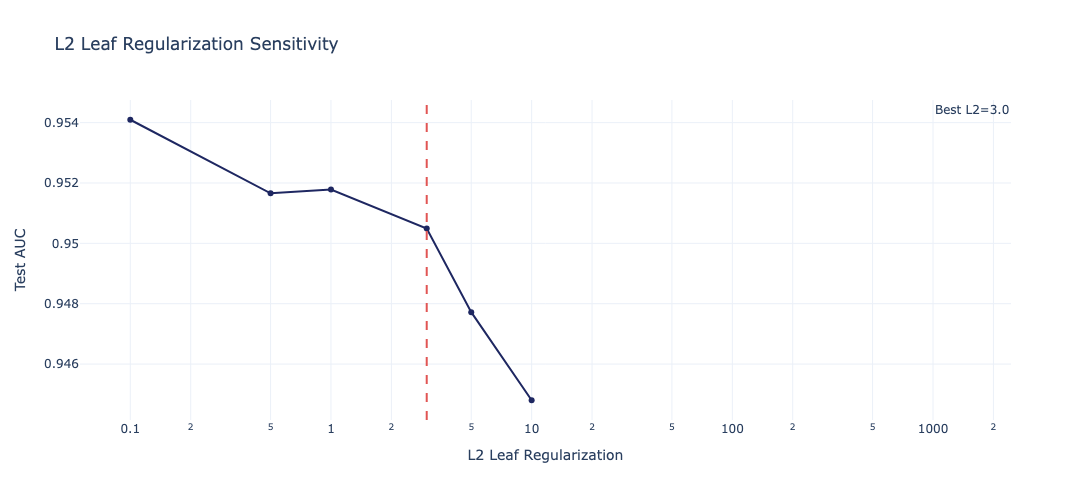

  Saved: outputs/catboost/l2_regularization_sensitivity.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/catboost/l2_regularization_sensitivity.html')

In [11]:
# Sweep L2 regularization with fixed other parameters
best_cb_params = best_cb.get_params()
l2_values = [0.1, 0.5, 1.0, 3.0, 5.0, 10.0]
l2_results = []

for l2 in l2_values:
    cb_l2 = CatBoostClassifier(
        iterations=best_cb_params.get("iterations", 100),
        depth=best_cb_params.get("depth", 6),
        learning_rate=best_cb_params.get("learning_rate", 0.1),
        l2_leaf_reg=l2,
        subsample=best_cb_params.get("subsample", 1.0),
        scale_pos_weight=pos_weight,
        random_state=RANDOM_STATE,
        verbose=0,
    )

    cb_l2.fit(X_train_prep, y_train, verbose=False)
    y_score_l2 = cb_l2.predict_proba(X_test_prep)[:, 1]

    l2_results.append({
        "l2_leaf_reg": l2,
        "auc": roc_auc_score(y_test, y_score_l2),
    })

df_l2 = pd.DataFrame(l2_results)
fig_l2 = go.Figure()
fig_l2.add_trace(go.Scatter(
    x=df_l2["l2_leaf_reg"], y=df_l2["auc"],
    name="Test AUC", line=dict(color=COLORS["navy"], width=2),
    mode="lines+markers",
))
fig_l2.add_vline(x=best_cb_params.get("l2_leaf_reg", 3), line_dash="dash", line_color=COLORS["red"],
                  annotation_text=f"Best L2={best_cb_params.get('l2_leaf_reg', 3)}")
fig_l2.update_layout(
    title="L2 Leaf Regularization Sensitivity",
    xaxis_title="L2 Leaf Regularization",
    xaxis_type="log",
    yaxis_title="Test AUC",
    height=500, width=700,
)
fig_l2.show()
save_chart(fig_l2, MODEL_SLUG, "l2_regularization_sensitivity")

---
## 10. Diagnostic Charts


Saving universal charts for CatBoost:
  Saved: outputs/catboost/roc_curve.html
  Saved: outputs/catboost/precision_recall_curve.html
  Saved: outputs/catboost/confusion_matrix.html
  Saved: outputs/catboost/threshold_sweep.html


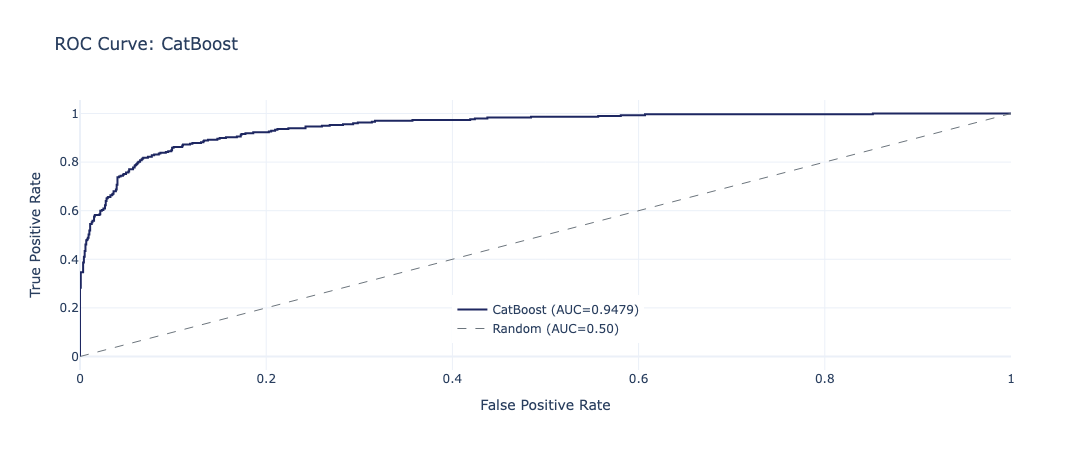

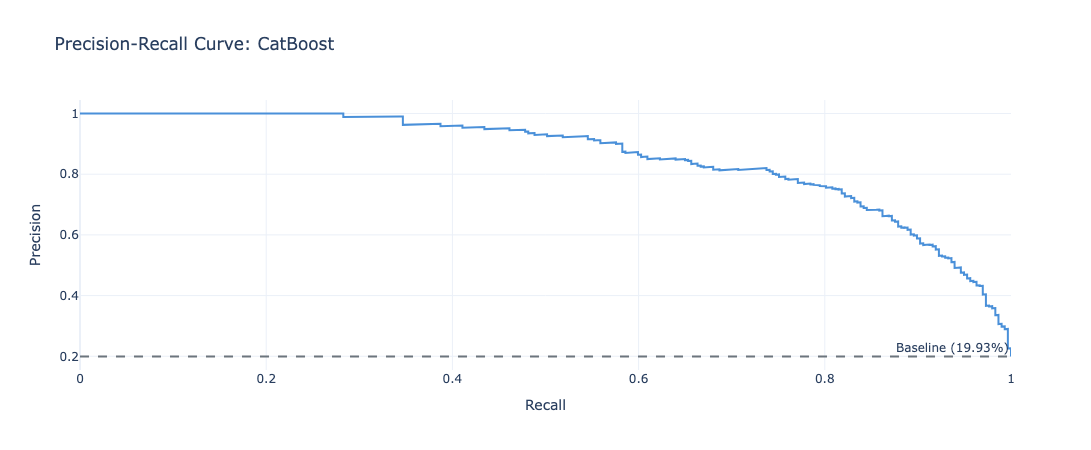

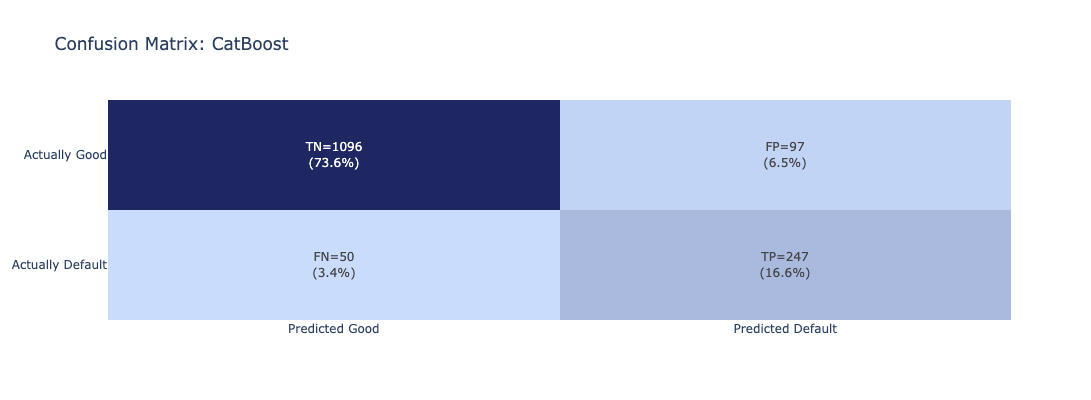

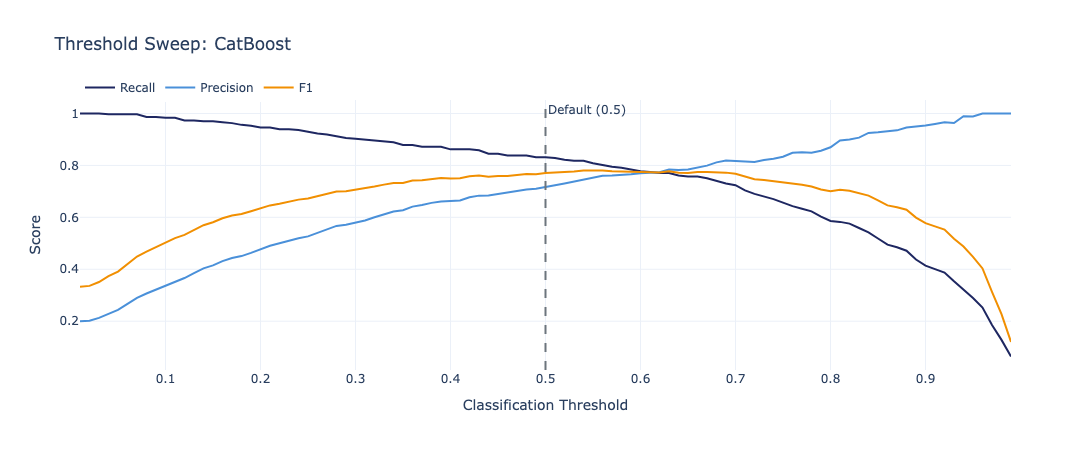

In [12]:
# Generate and save all universal charts
charts = save_all_universal_charts(y_test, y_pred, y_score, MODEL_NAME, MODEL_SLUG)

for name, fig in charts.items():
    fig.show()

---
## 11. Summary

### Where CatBoost Sits on the Tradeoff Spectrum

CatBoost with `scale_pos_weight` balancing lands in the **balanced zone** on the recall-precision spectrum. The ordered boosting approach and symmetric trees provide strong regularization, preventing overfitting better than untuned XGBoost or LightGBM. By tuning depth, learning_rate, and l2_leaf_reg, you can shift toward more aggressive recall or more conservative precision.

### Strengths for This Problem
- **Native categorical handling**: CatBoost's ordered target encoding prevents target leakage without needing one-hot encoding. This is a major advantage when categorical features are present (like HMEQ's REASON and JOB).
- **Ordered boosting**: Prevents the subtle target leakage problem in standard gradient boosting with categorical features. More honest estimates of model performance on unseen data.
- **Symmetric trees**: Reduce overfitting and produce more stable models. Tree structure is less sensitive to small data changes compared to asymmetric trees.
- **Strong regularization**: Out-of-the-box, CatBoost is well-regularized by default (symmetric trees, depth control). Requires less tuning than XGBoost.
- **Good class imbalance handling**: `scale_pos_weight` directly addresses minority class. Works well on imbalanced problems.
- **Fast on categorical data**: Avoids the explosion of features from one-hot encoding, keeping training fast.
- **Production-ready**: Used by leading companies (Yandex, etc.). Good documentation and active community.

### Limitations for This Problem
- **Slower than LightGBM**: LightGBM's histogram-based splitting is faster. CatBoost is still fast compared to sklearn but slower than modern competitors.
- **Hyperparameter tuning**: While well-regularized by default, tuning can still improve results. The manual grid search (due to sklearn incompatibility) is less convenient than using GridSearchCV.
- **Ordered encoding adds variance**: The randomized permutations in ordered target encoding add stochasticity. Multiple runs may produce different results.
- **Less widely adopted than XGBoost**: XGBoost has a larger ecosystem (more integrations, more examples). CatBoost is growing but less mainstream.
- **Calibration**: Default CatBoost probabilities may need calibration for decision thresholds.
- **Feature interaction transparency**: Like all boosted models, CatBoost implicitly captures interactions but does not expose them explicitly.

### Key Takeaway
CatBoost is the **best choice for datasets with categorical features** where you want to avoid one-hot encoding. The ordered boosting prevents a real (but often overlooked) source of overfitting: target leakage in categorical encoding. For loan default prediction with REASON and JOB categories, CatBoost often requires less feature engineering and tuning than XGBoost, while producing models that generalize better. Trade-off: slightly slower training than LightGBM, but the categorical advantage is often worth it.

---
*Notebook by Trinidad Cisneros — MIT Applied Data Science Program, April 2026*